## Pedestrian Walks with OpenStreetMap
這邊我用 `osmnx` 這個 package 來畫出以我的位置（綜合教學館）為中心，距離 1000m 以內的所有人行步道。 `osmnx` 是直接透過 [OpenStreetMap](https://www.openstreetmap.org/#map=17/25.017693/121.537564) 提供的 OverpassAPI 來取得路徑地圖，我覺得準確率蠻高的，在管院附近連土地公小徑跟管院草皮的兩條步道都有準確畫出來，感覺不需要特別校正。  
關於 `osmnx` 的詳細資料列在下面：
- [Modeling and Analyzing Urban Networks and Amenities With OSMnx](https://onlinelibrary.wiley.com/doi/10.1111/gean.70009)
- [OSMNX Documentation](https://osmnx.readthedocs.io/en/stable/)

In [1]:
import osmnx as ox

In [2]:
# Load graph from OSM file (pedestrian network)
G = ox.graph_from_point((25.017693,121.537564), dist=1000, network_type="walk")

In [3]:
# ox.plot_graph(G)

## Overlaying Streets and Buildings
這邊我試著把存成 geojson 格式的建築物資料用 `geopandas` 讀出，然後把建築物資料（平面）跟可以走的人行道一起畫成地圖。（橫軸會長這樣純粹是 matplotlib.pyplot 採用的科學符號的關係，這個很容易調整，但反正我們也不是要用 python 視覺化所以其實沒差）。  
這部分的流程主要是我用前面那個 Street Map 的圖去知道我大概要抓哪個範圍以內的資料（前面的 Street Map 範圍是用一個點當定位點，選距離定位點以內一定距離的步道資料），那我們就也只需要這對應的範圍的建築物資料，這樣可以避免需要去讀取整個大安區的建築物資料。總之我就先去抓了 Street Map 節點的最大最小值（這樣可以框出街區的範圍），然後用 `shapely.geometry` 去界定出一個 `bbox`，然後用這個 `bbox` 去限制擷取的建築物資料的範圍。

In [4]:
import geopandas as gpd
from shapely.geometry import box

In [5]:
# Get bounding box from network
nodes, edges = ox.graph_to_gdfs(G)
xmin, ymin, xmax, ymax = nodes.total_bounds
bbox = box(xmin, ymin, xmax, ymax)

# Load only buildings that intersect with bbox
buildings = gpd.read_file("./geojsons/4342.json", bbox=bbox)

In [6]:
import matplotlib.pyplot as plt

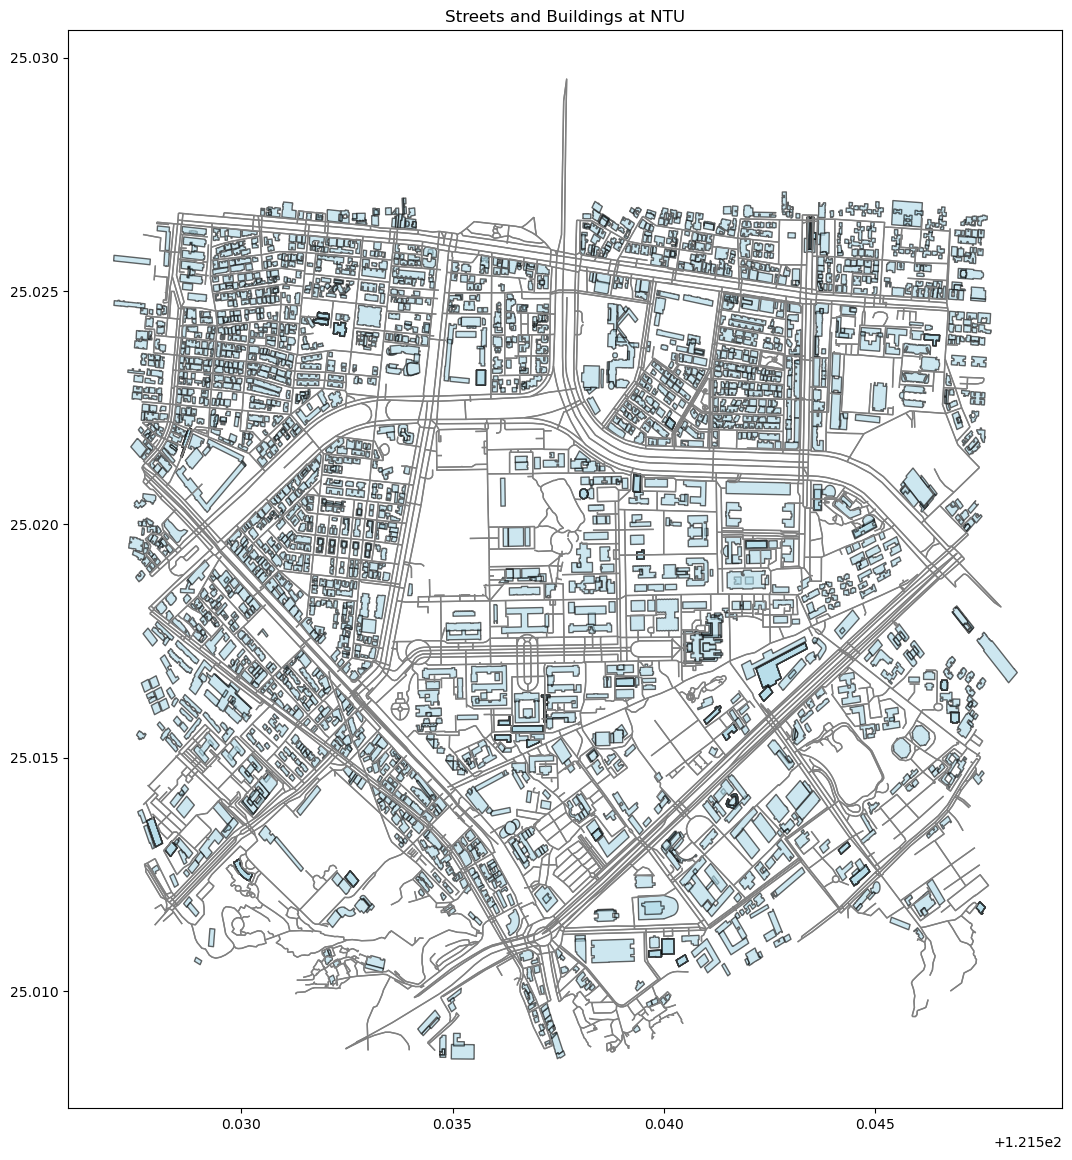

In [7]:
# Plot both
fig, ax = plt.subplots(figsize=(14, 14))

# Plot edges (streets)
edges.plot(ax=ax, linewidth=1, color="gray")

# Plot buildings
buildings.plot(ax=ax, facecolor="lightblue", edgecolor="black", alpha=0.6)

plt.title("Streets and Buildings at NTU")
plt.show()

## Compute Shadows and Overlay with Streets and Buildings
這邊是用 `pvlib` 來計算在某個位置，特定時區下，特定時間的太陽方位。我們會計算太陽的方位角 (azimuth) 跟太陽的高度角/高度 (altitude)，然後用這個資料去換算特定高度的建築物在這個太陽方位時會產生什麼形狀的陰影（陰影投影在地上的面積跟形狀）。陰影計算的函數是 `project_shadow`，我們用這個函數處理每棟建築物就可以順利算出在我們特定區域裡面的所有建築物的陰影。

In [8]:
import pvlib
import pandas as pd

In [9]:
# Location and time
lat, lon = 25.017693, 121.537564
time = pd.Timestamp("2025-09-24 16:00:00", tz="Asia/Taipei")

# Create location
location = pvlib.location.Location(lat, lon, tz="Asia/Taipei")

# Get solar position
solpos = location.get_solarposition(time)

azimuth = solpos['azimuth'].iloc[0]          # degrees clockwise from north
altitude = solpos['apparent_elevation'].iloc[0]  # degrees above horizon

print("Azimuth:", azimuth, "Altitude:", altitude)

Azimuth: 257.5215682059621 Altitude: 23.56715276825401


In [10]:
import numpy as np
from shapely.affinity import translate
from shapely.geometry import Polygon
from shapely.ops import unary_union

In [11]:
def project_shadow(building, height, azimuth, altitude):
    """
    Project an elongated shadow polygon attached to the building footprint.
    """
    if altitude <= 0:
        return None  # sun below horizon → no shadow

    # Shadow length
    shadow_len = height / np.tan(np.radians(altitude))

    # Shadow direction (opposite of sun)
    angle = np.radians(azimuth + 180)
    dx = shadow_len * np.sin(angle)
    dy = shadow_len * np.cos(angle)

    # Shifted footprint
    shadow_tip = Polygon([(x + dx, y + dy) for x, y in building.exterior.coords])

    # Union of building footprint + shadow tip footprint
    shadow_poly = unary_union([building, shadow_tip]).convex_hull

    return shadow_poly

這邊要注意的事情是，在計算建築物的陰影之前，要先把建築物的資料轉換成 EPSG:3857 才能用來計算地面上的陰影面積，然後計算後再把陰影的資料轉回 EPSG:4326。  
EPSG:3857 是地面上二維地圖 (map)，單位會是公尺 (m)，然後 EPSG:4236 是有點像地球曲面 (globe)，單位是度 (degrees)，兩種都是 web mapping 常用的，但做地面陰影計算的時候要用二維地圖且以公尺為單位。

In [12]:
# Reproject buildings to Web Mercator (units in meters)
buildings_m = buildings.to_crs(epsg=3857)

# If no height field, add one
if "height" not in buildings_m.columns:
    buildings_m["height"] = 20  # default height (meters)

# Compute shadows in EPSG:3857 (meters!)
shadows = []
for _, row in buildings_m.iterrows():
    s = project_shadow(row.geometry, row["height"], azimuth, altitude)
    if s:
        shadows.append(s)

# Build shadow GeoDataFrame with same CRS as buildings_m
shadow_gdf = gpd.GeoDataFrame({"geometry": shadows}, crs=buildings_m.crs)

# Reproject back to EPSG:4326 for plotting with OSM streets
shadow_gdf = shadow_gdf.to_crs(epsg=4326)

然後在這邊如果用 `mticker` 的 `FormatStrFormatter` 就可以避免 matplotlib 的 science notation 造成經緯度標記怪怪的問題了。（但這應該不重要）

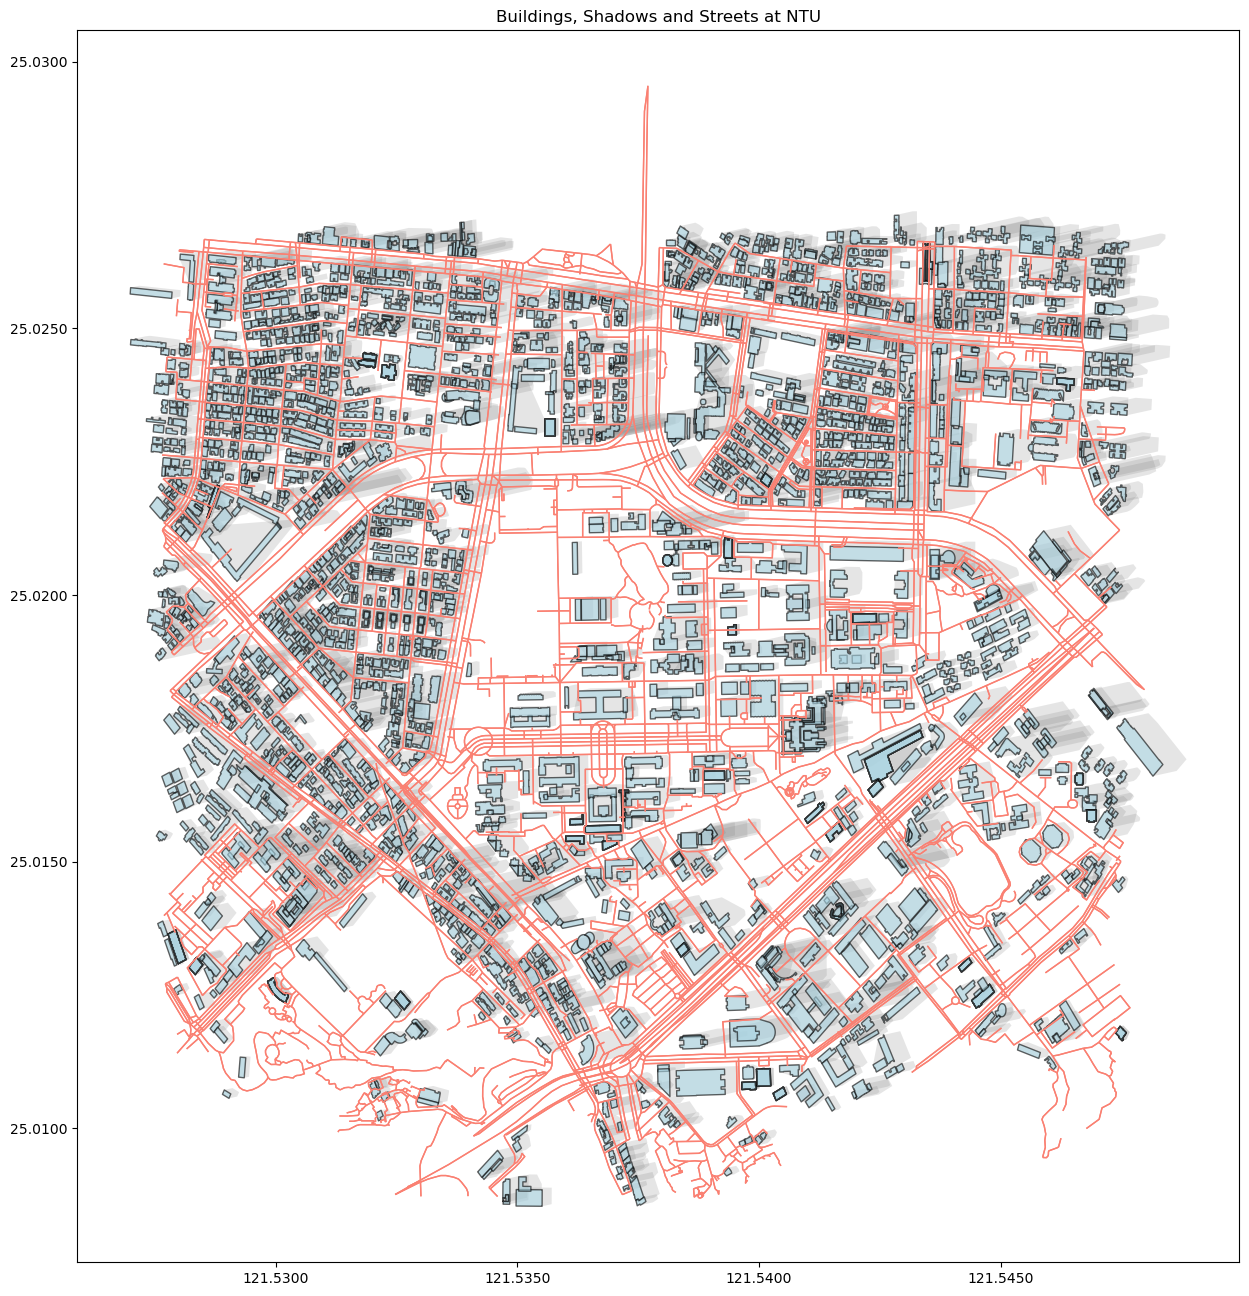

In [13]:
import matplotlib.ticker as mticker

# Plot
fig, ax = plt.subplots(figsize=(16, 16))
edges.plot(ax=ax, color="salmon", linewidth=1)
shadow_gdf.plot(ax=ax, facecolor="gray", alpha=0.2)
buildings.plot(ax=ax, facecolor="lightblue", edgecolor="black", alpha=0.6)

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
plt.title("Buildings, Shadows and Streets at NTU")
plt.show()

我們也可以 display 陰影跟建築物的 GeoDataFrame 看看資料長怎樣：

In [14]:
display(shadow_gdf.head())

,geometry
0,"POLYGON ((121.53481 25.00862, 121.53471 25.008..."
1,"POLYGON ((121.53484 25.00857, 121.53483 25.008..."
2,"POLYGON ((121.53431 25.00904, 121.53427 25.009..."
3,"POLYGON ((121.53029 25.01379, 121.53003 25.014..."
4,"POLYGON ((121.53458 25.01412, 121.53447 25.014..."


In [15]:
display(buildings.head())

,height,color,roofColor,geometry
0,19.202400,"rgb(204,0,255)","rgb(204,0,255)","POLYGON ((121.53471 25.00863, 121.53471 25.008..."
1,19.177000,"rgb(204,0,255)","rgb(204,0,255)","POLYGON ((121.53485 25.00899, 121.53484 25.008..."
2,13.131800,"rgb(51,51,102)","rgb(51,51,102)","POLYGON ((121.53438 25.00919, 121.53444 25.009..."
3,48.082199,"rgb(204,0,102)","rgb(204,0,102)","POLYGON ((121.53041 25.01419, 121.53032 25.014..."
4,62.382399,"rgb(204,0,102)","rgb(204,0,102)","POLYGON ((121.53414 25.01464, 121.53418 25.014..."


## Integration: Shadow Routing from Building Shadows
這邊有些函數可能前面有定義過，但這邊有經過進一步的整理跟模組化，最後可以只看這段就好，前面基本上只是一些資料的呈現跟嘗試，這邊才是真的要把所有東西都組在一起，然後試著去實踐出路徑搜尋的功能。

首先，在給定一組起點和終點之後，我們要能夠抓取對應的地圖資料，但我們又不想匯入整個地區的地圖，因為這樣會導致運算效率很低，所以這邊的做法是以起點和終點的座標當作對角去畫出一個方框 (polygon)，然後為了留一些緩衝空間，會額外抓取在 buffer 範圍內的資料（這邊 buffer 先暫定 200 m），可以在下面的 example 裡面看到我們用這些函數去標示出從總圖（起點）到新體（終點）的方框，那我們基本上就會在這個範圍內去做後續的路徑搜尋。

In [16]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import box

def make_bounding_polygon(start_lat, start_lon, end_lat, end_lon, buffer=200):
    """
    Create a bounding polygon from start and end points with a buffer (meters).
    buffer is converted from meters to degrees approx. (1 deg ~ 111 km).
    """
    north = max(start_lat, end_lat) + buffer / 111111
    south = min(start_lat, end_lat) - buffer / 111111
    east  = max(start_lon, end_lon) + buffer / 111111
    west  = min(start_lon, end_lon) - buffer / 111111
    return box(west, south, east, north)

def extract_streets(polygon):
    """
    Extract walking street network inside a polygon from OSM.
    Returns OSMnx graph + GeoDataFrames (nodes, edges).
    """
    G = ox.graph_from_polygon(polygon, network_type="walk", simplify=True, retain_all=False)
    nodes, edges = ox.graph_to_gdfs(G)
    return G, nodes, edges

def extract_buildings(building_file, polygon):
    """
    Extract buildings from a local GeoJSON/JSON file clipped to polygon.
    """
    buildings = gpd.read_file(building_file, bbox=polygon)
    # Ensure heights exist
    if "height" not in buildings.columns:
        buildings["height"] = 20  # default value
    return buildings

/var/folders/y2/1952s8614n57zxk25s_41fym0000gn/T/ipykernel_93361/4240540904.py:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


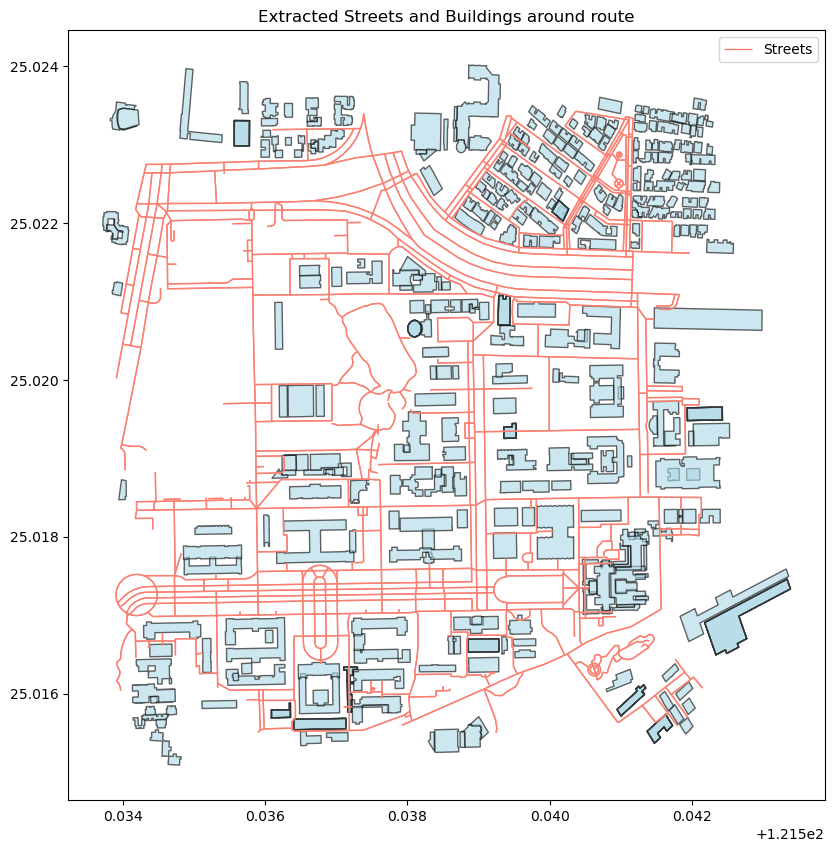

In [19]:
# Start & End
start_lat, start_lon = 25.0173, 121.540428
end_lat, end_lon     = 25.021645, 121.535697

# Create bounding polygon
polygon = make_bounding_polygon(start_lat, start_lon, end_lat, end_lon, buffer=200)
G, nodes, edges = extract_streets(polygon)

# Extract buildings
buildings = extract_buildings("./geojsons/4342.json", polygon)

# Plot to check
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, linewidth=1, color="salmon", label="Streets")
buildings.plot(ax=ax, facecolor="lightblue", edgecolor="black", alpha=0.6, label="Buildings")

plt.legend()
plt.title("Extracted Streets and Buildings around route")
plt.show()

前面在計算陰影的時候我們分成了幾個步驟進行，先計算太陽的方位，然後將建築物的座標轉換成以公尺為單位的 EPSG:3857 後計算陰影，再將陰影資料轉回 EPSG:4326 的曲面座標（以角度為單位）並回傳，在這邊我們把這幾個連續的步驟合併成單一個 `project_shadows` 的函數。

In [22]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
from shapely.ops import unary_union
import pvlib

def project_shadows(buildings, lat, lon, time, tz="Asia/Taipei", default_height=20):
    """
    Compute building shadows given buildings, location, and time.

    Parameters
    ----------
    buildings : GeoDataFrame
        Building footprints in EPSG:4326 (lat/lon).
        Must have a "geometry" column. If no "height" column, default is used.
    lat, lon : float
        Approximate location for solar position (degrees).
    time : pd.Timestamp
        Timestamp (timezone-aware preferred).
    tz : str
        Timezone string for solar calculations.
    default_height : float
        Default building height (meters) if "height" column is missing.

    Returns
    -------
    GeoDataFrame
        Shadow polygons in EPSG:4326, aligned with OSMnx streets.
    """

    # Ensure height exists
    if "height" not in buildings.columns:
        buildings["height"] = default_height

    # Compute sun position
    loc = pvlib.location.Location(lat, lon, tz=tz)
    solpos = loc.get_solarposition(time)
    azimuth = solpos.azimuth.iloc[0]
    altitude = solpos.elevation.iloc[0]

    if altitude <= 0:
        print("Sun below horizon, no shadows.")
        return gpd.GeoDataFrame(columns=["geometry"], crs="EPSG:4326")

    # Convert to Web Mercator (meters)
    buildings_m = buildings.to_crs(epsg=3857)

    # Compute shadows in EPSG:3857
    shadows = []
    for _, row in buildings_m.iterrows():
        shadow_len = row["height"] / np.tan(np.radians(altitude))
        angle = np.radians(azimuth + 180)  # opposite sun
        dx = shadow_len * np.sin(angle)
        dy = shadow_len * np.cos(angle)

        # Shift building footprint
        shadow_tip = Polygon([(x + dx, y + dy) for x, y in row.geometry.exterior.coords])

        # Union footprint + tip
        shadow_poly = unary_union([row.geometry, shadow_tip]).convex_hull
        shadows.append(shadow_poly)

    # Return shadows reprojected back to EPSG:4326
    shadow_gdf = gpd.GeoDataFrame({"geometry": shadows}, crs=buildings_m.crs)
    return shadow_gdf.to_crs(epsg=4326)

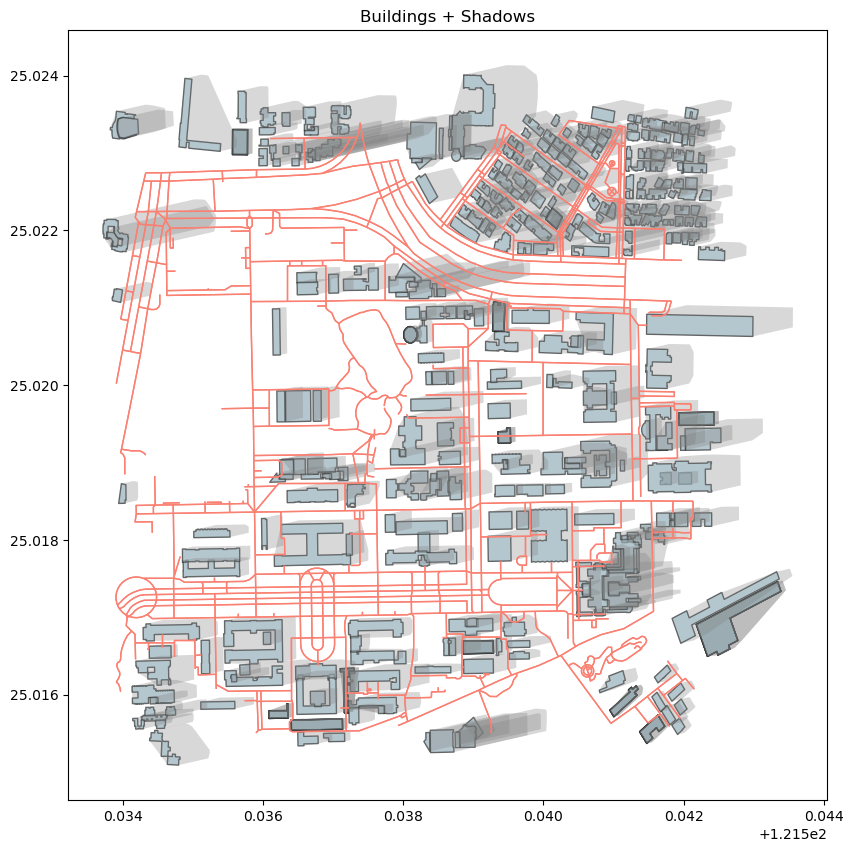

In [25]:
# Example: compute shadows
time = pd.Timestamp("2025-09-25 16:00:00", tz="Asia/Taipei")

shadow_gdf = project_shadows(
    buildings,
    lat=start_lat,
    lon=start_lon,
    time=time
)

# Plot check
fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, color="salmon", linewidth=1)
buildings.plot(ax=ax, facecolor="lightblue", edgecolor="black", alpha=0.6)
shadow_gdf.plot(ax=ax, facecolor="gray", alpha=0.3)
plt.title("Buildings + Shadows")
plt.show()

為了有辦法計算一條路上到底有多少陰影面積，我們會在這條路上隨機抽樣，以固定的間隔 (e.g., 15m) 抽出樣本點，後續一個 edge 上有多少個樣本點會落在前面計算的 shadow 的 polygon 裏面，並用這個比例來加權每個邊（陰影越少的路徑權重越高），最後再加上距離的權重（總距離越長的路徑權重越高），並進行 minimum cost (weight) path finding，就可以找到綜合陰影和距離所得出的最佳路徑，而使用者也可以調整自己對陰影和距離的優先程度（e.g., 比較在乎陰影、比較在乎距離、一樣在乎等等）。

In [28]:
import geopandas as gpd
import numpy as np
from shapely.geometry import LineString, Point

def add_samples_to_edges(edges, spacing=30):
    # Work in meters
    edges_m = edges.to_crs(epsg=3857)
    
    samples_list = []
    for geom in edges_m.geometry:
        if geom is None or geom.is_empty:
            samples_list.append([])
            continue
        length = geom.length
        if length < spacing:
            pts = [geom.interpolate(0.5, normalized=True)]
        else:
            num = int(length // spacing)
            pts = [geom.interpolate(i/num, normalized=True) for i in range(num+1)]
        samples_list.append(pts)
    
    # Convert samples back to original CRS
    gdf_samples = gpd.GeoSeries([pt for pts in samples_list for pt in pts], crs=edges_m.crs).to_crs(edges.crs)
    
    # Re-split into per-edge lists
    reprojected_samples = []
    idx = 0
    for pts in samples_list:
        reprojected_samples.append(gdf_samples[idx:idx+len(pts)].tolist())
        idx += len(pts)
    
    edges = edges.copy()
    edges["samples"] = reprojected_samples
    return edges

                                                                   geometry  \
u        v           key                                                      
51413397 3873376210  0    LINESTRING (121.5359 25.01731, 121.5359 25.01724)   
         6657790527  0    LINESTRING (121.5359 25.01731, 121.5359 25.01739)   
         12252572486 0    LINESTRING (121.5359 25.01731, 121.53548 25.01...   
         12234568157 0    LINESTRING (121.5359 25.01731, 121.53653 25.01...   
51413613 4932251930  0    LINESTRING (121.53717 25.01873, 121.53736 25.0...   

                                                                    samples  
u        v           key                                                     
51413397 3873376210  0      [POINT (121.53589779999999 25.017277650005266)]  
         6657790527  0       [POINT (121.53589659999999 25.01734950000525)]  
         12252572486 0    [POINT (121.53589720000001 25.0173136), POINT ...  
         12234568157 0    [POINT (121.53589720000001 25.

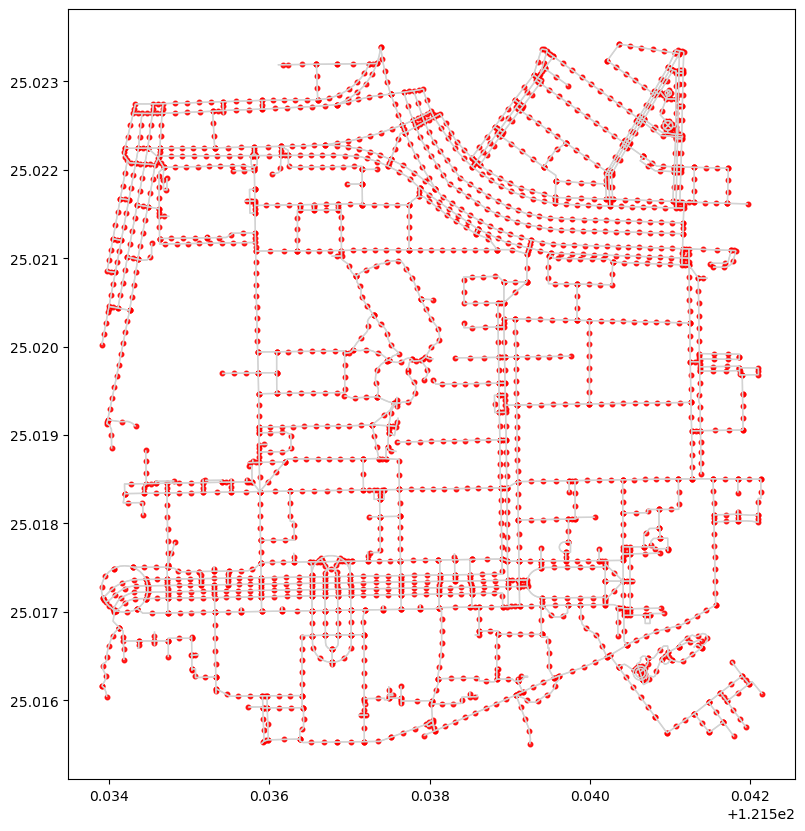

In [31]:
# Edges here are calculated earlier when we executed extract_streets
# G, nodes, edges = extract_streets(polygon)

edges_with_samples = add_samples_to_edges(edges, spacing=15)

# Check one row
print(edges_with_samples[["geometry", "samples"]].head())

# Quick plot to visualize samples
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
edges_with_samples.plot(ax=ax, color="lightgray", linewidth=1)
for pts in edges_with_samples["samples"]:
    xs = [p.x for p in pts]
    ys = [p.y for p in pts]
    ax.scatter(xs, ys, c="red", s=10, alpha=0.6)
plt.show()

這邊我們會計算一個 `shade_weight`，並把這個 attribute 加入到原本 edges 的 GeoDataFrame 中，這邊 `shade_weight` 的計算方式是去算每個 edge 上的抽樣點有多高的比例是落在陰影的 polygon 裡面的，所以 `shade_weight` 越高，代表這個 edge 的陰影佔比越高（越多陰影）。  
但我們同時也會考慮距離來做 routing，而且 routing 的演算法多數都是選最短路徑（總共的 weights/cost 最小的），所以在 `add_final_weight` 裡面，我們會計算 `shade_cost = 1 - shade_weight`，然後用 $\alpha$ 去調整對陰影和距離的權重，$\alpha$ 越高是越重視 shade，反之則是越重視 distance，我們會用這個去幫使用者加權。

In [32]:
def compute_shade_weights(edges, shadow_polys):
    shade_weights = []
    for samples in edges["samples"]:
        if not samples:  # no samples
            shade_weights.append(0.0)
            continue
        shaded = sum(any(pt.within(poly) for poly in shadow_polys) for pt in samples)
        frac = shaded / len(samples)
        shade_weights.append(frac)
    edges["shade_weight"] = shade_weights
    return edges


def add_final_weights(edges, alpha=0.5):
    # Work in projected CRS for distance
    edges_m = edges.to_crs(epsg=3857)
    max_len = edges_m.geometry.length.max()
    
    dist_weights = edges_m.geometry.length / max_len
    shade_costs  = 1 - edges["shade_weight"]  # lower = better shade
    
    edges["dist_weight"]  = dist_weights
    edges["final_weight"] = alpha * shade_costs + (1 - alpha) * dist_weights
    
    return edges

這邊就是做路徑演算法的部分，我們是用 Dijkstra's Algorithm 做 minimum weight graph traversal。

In [35]:
import networkx as nx
import osmnx as ox

def shadow_route(G, edges, start_lat, start_lon, end_lat, end_lon):
    # Find nearest nodes
    orig = ox.distance.nearest_nodes(G, start_lon, start_lat)
    dest = ox.distance.nearest_nodes(G, end_lon, end_lat)
    
    # Map edge weights back to graph
    edge_weights = edges["final_weight"].to_dict()  # index = (u,v,key)
    for u, v, k, data in G.edges(keys=True, data=True):
        data["weight"] = edge_weights.get((u,v,k), 1.0)  # fallback if missing
    
    # Shortest path with Dijkstra
    route = nx.shortest_path(G, orig, dest, weight="weight")
    return route

然後我們可以用前面的函數去計算，先前我們已經在 edge 上面做過抽樣得到 `edges_with_samples`，這邊我們就把這個 `edges_with_samples` 連同陰影的 GeoDataFrame 裡面的 `geometry` 屬性傳進 `compute_shade_weight` 函數，這個函數會在 `edges_with_samples` 裡面加入一個 `shade_weight` 的屬性，再把新的 `edges_with_samples` （包含陰影權重）連同 $\alpha$ 值傳進 `add_final_weights`，這邊的 $\alpha$ 也可以讓使用者自己定義，然後我們可以再將整個 Street Graph (G)，連同權重和起點終點一併傳進 `shadow_route` 做路徑搜尋。

In [36]:
edges_with_weights = compute_shade_weights(edges_with_samples, list(shadow_gdf.geometry))
edges_with_weights = add_final_weights(edges_with_weights, alpha=0.5)

# Run shadow-aware route
route = shadow_route(G, edges_with_weights, start_lat, start_lon, end_lat, end_lon)

print("Route nodes:", route)

Route nodes: [9670502264, 9670502254, 9670499832, 9670451191, 2179826578, 9670452320, 2179826589, 2281072954, 321562766, 5022237171, 12246166483, 12246158893, 12246187716, 12246166489, 1936977820, 321562762, 4931508502, 5258099175, 4931508501, 12715100923, 4436343767, 6401808759, 2021433584, 2021433587, 338639724, 4308533690, 4308533693, 6237671376, 12244651603, 12244662733, 12244647895, 12244647888, 12244647897]


我們可以先看看 `shadow_weight` 和 `final_weight` 在地圖上的呈現，可以看到蠻明顯的陰影面積越多的地方 `shadow_weight` 就越高，那 `final_weight` 就沒有那麼絕對，因為還包含了距離的因素，距離很遠的點即使陰影很多，還是可能分配到較高的 weight/cost。  
這邊要注意的是 `shadow_weight` 是越高陰影越多，所以我用紅藍色標示路徑：藍色的區域 weight 比較高，代表陰影比較多，路徑比較涼；紅色則是相反，紅色的路徑 weight 比較低，代表陰影比例低，路徑比較熱，這都是只考慮建築物，還沒考慮行道樹的做法。
那 `final_weight` 則是越小越好，為了避免困惑我這邊換一個顏色做標示。這邊暗色（紫色）是比較不好的路徑，而亮色（黃色橘色）則是使用者會比較偏好的路徑，也對應到我們後面標注路線使用的黃色。

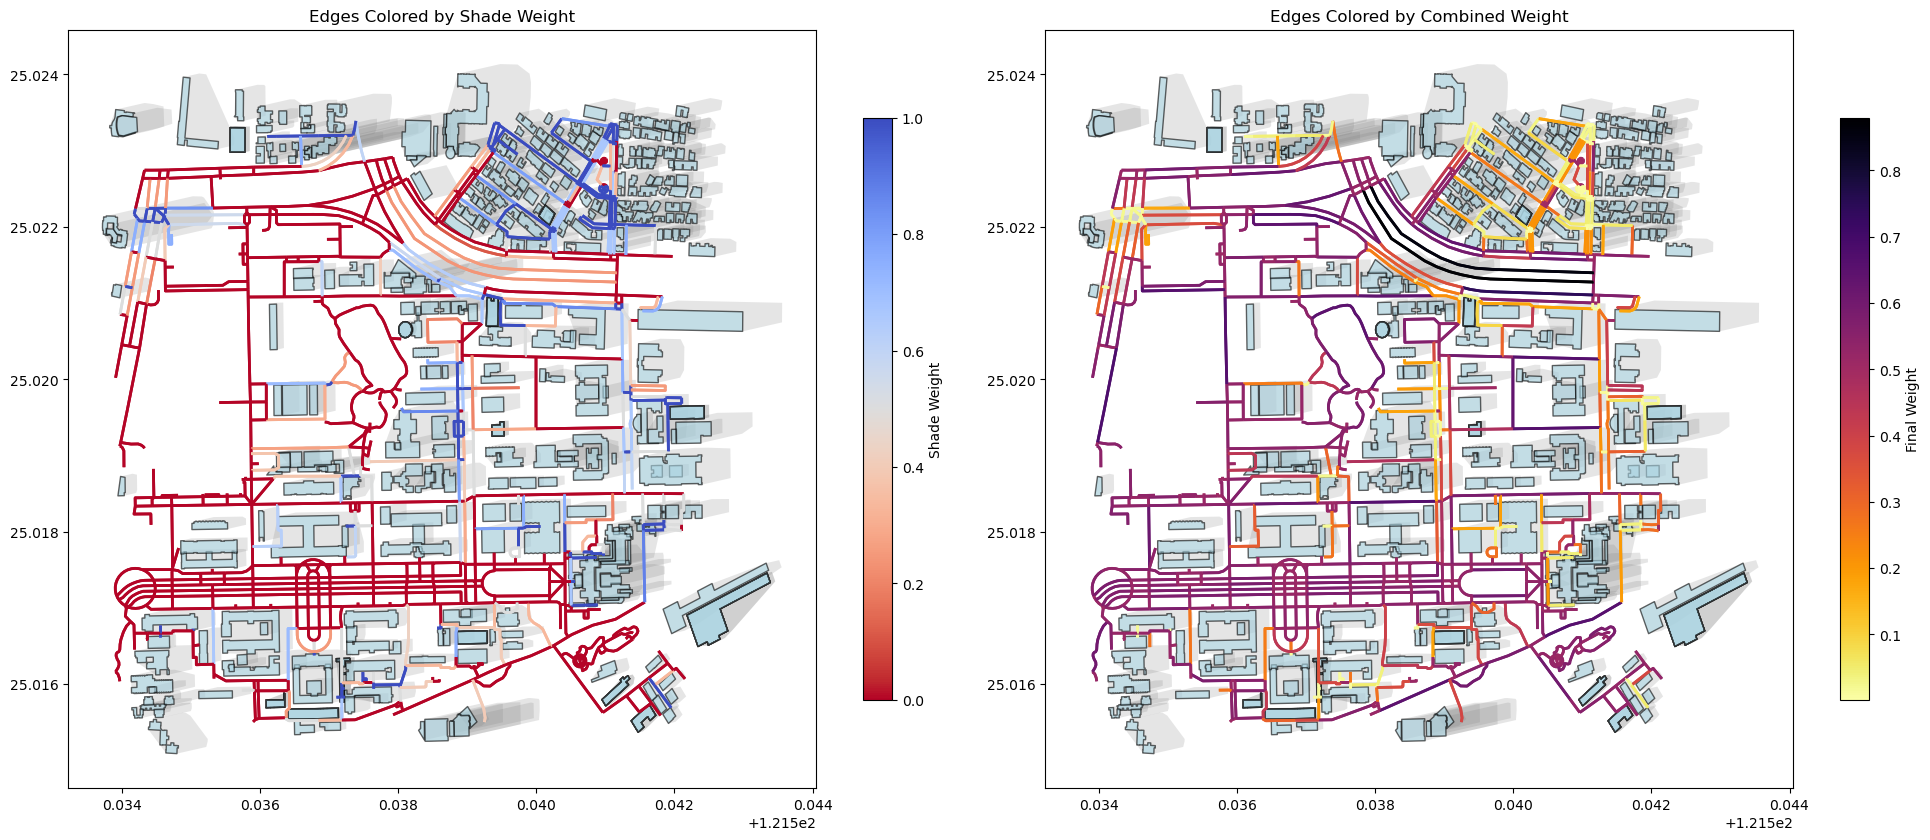

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# --- Left: shadow weight ---
edges_with_weights.plot(
    ax=axes[0], column="shade_weight", cmap="coolwarm_r", linewidth=2, legend=True,
    legend_kwds={"shrink": 0.6, "label": "Shade Weight"}
)
shadow_gdf.plot(ax=axes[0], facecolor="gray", alpha=0.2)
buildings.plot(ax=axes[0], facecolor="lightblue", edgecolor="black", alpha=0.6)
axes[0].set_title("Edges Colored by Shade Weight")


# --- Right: combined weight ---
edges_with_weights.plot(
    ax=axes[1], column="final_weight", cmap="inferno_r", linewidth=2, legend=True,
    legend_kwds={"shrink": 0.6, "label": "Final Weight"}
)
shadow_gdf.plot(ax=axes[1], facecolor="gray", alpha=0.2)
buildings.plot(ax=axes[1], facecolor="lightblue", edgecolor="black", alpha=0.6)
axes[1].set_title("Edges Colored by Combined Weight")

plt.tight_layout()
plt.show()

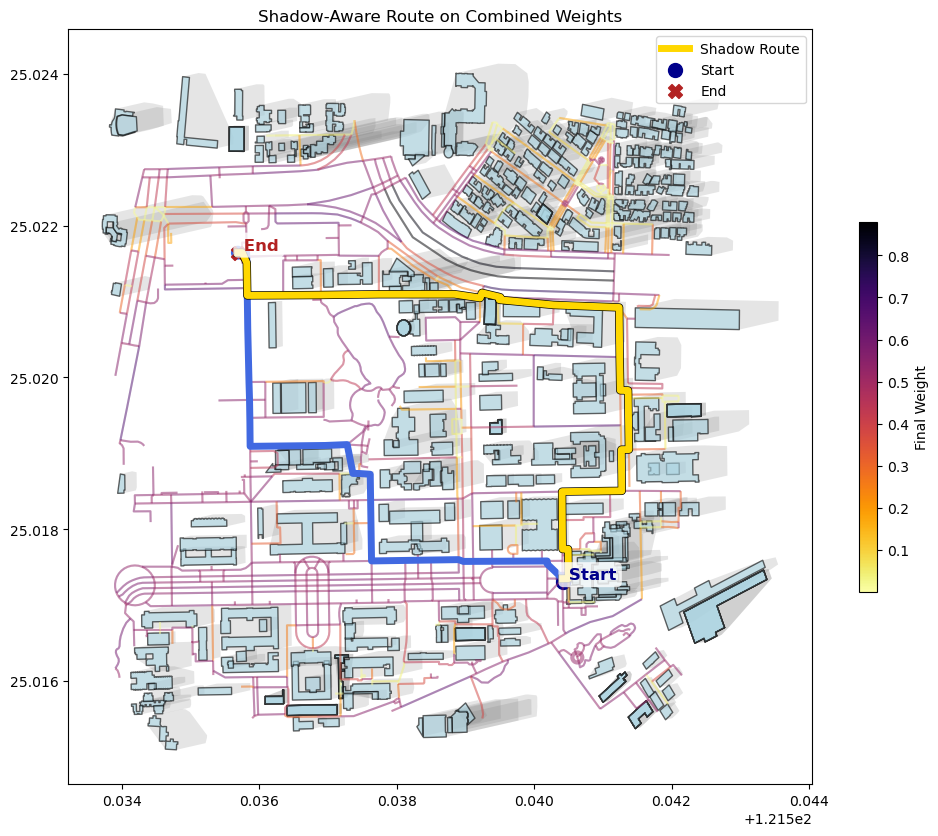

In [72]:
# --- Large plot with route overlay ---
fig, ax = plt.subplots(figsize=(12, 12))

# Edges colored by combined weights
edges_with_weights.plot(
    ax=ax, column="final_weight", cmap="inferno_r", linewidth=1.5, legend=True, alpha=0.3,
    legend_kwds={"shrink": 0.4, "label": "Final Weight"}
)

# OpenStreetMap Route
ox.plot_graph_route(
    G, default_route, ax=ax,
    route_color="royalblue", route_linewidth=5, route_alpha=1,
    orig_dest_size=100, show=False, close=False
)

# Overlay the route
route_nodes = nodes.loc[route]
ax.plot(route_nodes.x, route_nodes.y, color="black", linewidth=6)
ax.plot(route_nodes.x, route_nodes.y, color="gold", linewidth=5, label="Shadow Route")

# Shadows and buildings
shadow_gdf.plot(ax=ax, facecolor="gray", alpha=0.2)
buildings.plot(ax=ax, facecolor="lightblue", edgecolor="black", alpha=0.6)

# Mark start and end points
ax.scatter(start_lon, start_lat, c="darkblue", s=100, marker="o", label="Start")
ax.scatter(end_lon, end_lat, c="firebrick", s=100, marker="X", label="End")

# Add text labels with background box
ax.text(
    start_lon, start_lat, " Start",
    fontsize=12, color="darkblue", weight="bold", va="bottom", ha="left",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", boxstyle="round,pad=0.3")
)
ax.text(
    end_lon, end_lat, " End",
    fontsize=12, color="firebrick", weight="bold", va="bottom", ha="left",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", boxstyle="round,pad=0.3")
)

ax.legend()
plt.title("Shadow-Aware Route on Combined Weights")
plt.show()